In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import sys
sys.path.append("../")

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [7]:
# import logging, sys
# for h in logging.root.handlers[:]:
#     logging.root.removeHandler(h)
# logging.basicConfig(
#     level=logging.ERROR,  # or DEBUG
#     stream=sys.stdout,  # send logs to the cell output
#     format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
# )
# logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
# logging.captureWarnings(True)

import logging
logging.disable(logging.CRITICAL)

In [116]:
# 2025-09-20 18:09:30,966 CRITICAL [ZODB.DB] DB.open() has 19 open connections with a pool_size of 7

In [8]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_q12")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_misc")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=False)
# irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

tenor
USD Swap OIS ATM frb1 to frb2 LCH Cleared     3.624905
USD Swap OIS ATM frb2 to frb3 LCH Cleared     3.581988
USD Swap OIS ATM frb3 to frb4 LCH Cleared     3.455416
USD Swap OIS ATM frb4 to frb5 LCH Cleared     3.358841
USD Swap OIS ATM frb5 to frb6 LCH Cleared     3.217512
USD Swap OIS ATM frb6 to frb7 LCH Cleared     3.134599
USD Swap OIS 3m ATM imm1 to 3m LCH Cleared    3.609953
USD Swap OIS 3m ATM imm2 to 3m LCH Cleared    3.410705
USD Swap OIS 3m ATM imm3 to 3m LCH Cleared    3.174000
USD Swap OIS 3m ATM imm4 to 3m LCH Cleared    3.028898
USD Swap OIS 6m ATM imm1 to 6m LCH Cleared    3.525891
USD Swap OIS 6m ATM imm2 to 6m LCH Cleared    3.306035
USD Swap OIS 6m ATM imm3 to 6m LCH Cleared    3.113600
USD Swap OIS 6m ATM imm4 to 6m LCH Cleared    3.020773
USD Swap OIS 1y ATM 1y to 1y LCH Cleared      3.027365
USD Swap OIS 1y ATM 2y to 1y LCH Cleared      3.164521
USD Swap OIS 1y ATM 3y to 1y LCH Cleared      3.350446
Name: rate, dtype: float64
SUCCESS: `func_tol` reached afte

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x2011a68c050>])

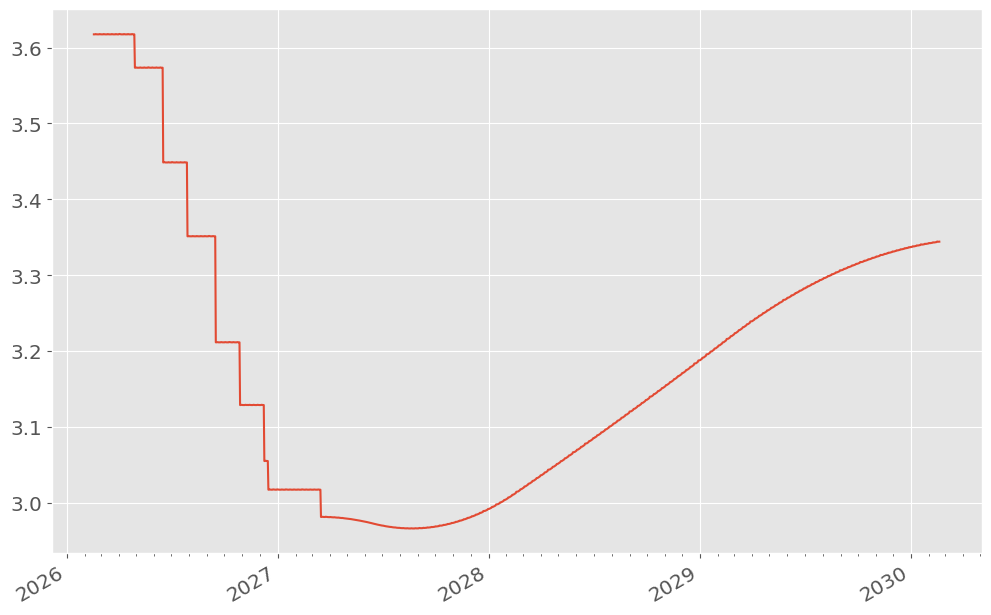

In [11]:
ts = datetime.date(2026, 2, 17)
# ts = NY_tz.localize(datetime.datetime(2025, 9, 24, 7, 00))
# ts = "live"

curve_handle = curve_mdp._get_curve(curve_name="USD-OIS-STIR-LCH", timestamp=ts)
curve_handle.handle().plot("1d")

In [81]:
ql.Settings.instance().evaluationDate = ql.Date(ts.day, ts.month, ts.year) 

schedule_aug55s = ql.Schedule(
    ql.Date(15, ql.August, 2025),
    ql.Date(15, ql.August, 2055),
    ql.Period(6, ql.Months),
    ql.UnitedStates(ql.UnitedStates.GovernmentBond),
    ql.ModifiedFollowing,
    ql.ModifiedFollowing,
    ql.DateGeneration.Backward,
    False,
)
settlementDays = 2
faceAmount = 100
coupons = [0.04750]
paymentDayCounter = ql.ActualActual(ql.ActualActual.ISMA)

aug55s = ql.FixedRateBond(settlementDays, faceAmount, schedule_aug55s, coupons, paymentDayCounter)

# ql.BondFunctions.duration(aug55s, 4.764 / 100, paymentDayCounter, ql.Compounded, ql.Semiannual, ql.Duration.Modified)

swap_curve = curve_handle.handle()
index = curve_handle.index()

pay_fixed = True
par_asset_swap = True 
asset_swap = ql.AssetSwap(
    pay_fixed,
    aug55s,
	aug55s.cleanPrice(4.752 / 100, paymentDayCounter, ql.Compounded, ql.Semiannual),
    index,
    -0.0,
    schedule_aug55s,
	curve_handle.index().dayCounter(),
    par_asset_swap,
)

In [82]:
asset_swap.setPricingEngine(ql.DiscountingSwapEngine(swap_curve))
asset_swap.fairSpread() * 10_000

77.39851502700631

In [65]:
irssfm = IRSwapStructureFunctionMap(curve=curve_handle)
q = IRSwapQuery(
    curve="USD-SOFR-1D",
    effective_date=datetime.date(2025, 9, 29),
    maturity_date=datetime.date(2055, 8, 15),
    structure=IRSwapStructure.OUTRIGHT,
    structure_kwargs={"bpv": 1},
)
pkg, rws = irssfm.apply(q.structure, tenor=q.tenor, effective_date=q.effective_date, maturity_date=q.maturity_date, **q.structure_kwargs)
IRSwapValueFunctionMap(curve=curve_handle, package=pkg, risk_weights=rws).apply(value=IRSwapValue.RATE)

3.9419781391046667

In [67]:
(3.9419781391046667 - 4.752) * 100

-81.00218608953331

In [6]:
def ql_cal_date_range(ql_cal: ql.Calendar, start: datetime.datetime, end: datetime.datetime):
    assert start.tzinfo is not None, "must be tz aware!"
    assert str(start.tzinfo) == str(end.tzinfo), "must be from same tz!"
    assert start.time() == end.time(), "must be same closes!"
    
    def _to_ql_date(dt: datetime.datetime):
        return ql.Date(dt.day, dt.month, dt.year)
    
    pd_range = pd.date_range(start=start, end=end, freq="1b")
    return [d for d in pd_range if ql_cal.isBusinessDay(_to_ql_date(d))]

In [7]:
tb = IRSwapsTB(mdp=curve_mdp)

In [ ]:
# start = datetime.date(2025, 1, 1)
# end = datetime.date(2025, 9, 26)

# start = NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00))
# end = NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00))


nycloses = ql_cal_date_range(
    ql_cal=ql.UnitedStates(ql.UnitedStates.GovernmentBond),
    start=NY_tz.localize(datetime.datetime(2025, 1, 1, 17, 00)),
    end=NY_tz.localize(datetime.datetime(2025, 3, 1, 17, 00)),
)
print(nycloses)

for close in nycloses:
    intraday = pd.date_range(
        start=NY_tz.localize(datetime.datetime(close.year, close.month, close.day, 7, 00)),
        end=NY_tz.localize(datetime.datetime(close.year, close.month, close.day, 17, 00)),
        freq="1min",
    )
    q = IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y")
    df = tb.get_timeseries(start=None, end=None, timestamps=intraday, queries=[q], n_jobs=12)

In [16]:
# intraday = pd.date_range(
#     start=NY_tz.localize(datetime.datetime(2025, 8, 1, 7, 00)),
#     end=NY_tz.localize(datetime.datetime(2025, 8, 1, 17, 00)),
#     freq="1min",
# )

# # q = IRSwapQuery(curve="USD-SOFR-1D", structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "1Yx1Y", "back_tenor": "2Yx1Y", "bpv": 1})
# # q = IRSwapQuery(
# #     curve="USD-SOFR-1D", structure=IRSwapStructure.FLY, structure_kwargs={"front_tenor": "2Y", "belly_tenor": "5Y", "back_tenor": "10Y", "bpv": 1}
# # )
# # q = IRSwapQuery(curve="USD-SOFR-1D", tenor="1Yx1Y")
# q = IRSwapQuery(curve="USD-SOFR-1D", tenor="10Y")
# df = tb.get_timeseries(start=None, end=None, timestamps=intraday, queries=[q], n_jobs=1)
# df

In [17]:
# plt.plot(df.index, df[q.col_name()])

In [10]:
# curve_mdp.bulk_get_data(request={"curve_name": "USD-SOFR-1D", "timestamps": ["live"], "ignore_cache": True})